In [2]:
#### Gather all scores into on dictionary named 'scores'

from granuscore.loader import JSONLineReader
from evaluation.qa_datasets.eval_datasets import DATASETS
from evaluation.config import PROJECT_DIR
from collections import defaultdict
import pandas as pd
import numpy as np

base_dir = f'{PROJECT_DIR}/data/qa_datasets'
output_dir = base_dir + 'outputs/'
models = ["deepseek-v3-2", "olmo-7b", "qwen3-06b", "qwen3-8b", "qwen3-8b-think", "qwen3-32b", "qwen3-235-a22b-instruct"]

dataset_names = DATASETS.keys()

scores = defaultdict(dict)
for model in models:
    for dataset_name in dataset_names:
        grades = JSONLineReader().read(f'{base_dir}/{dataset_name}/{model}/graded-{model}-{dataset_name}.jsonl')
        output_granularities = JSONLineReader().read(
            f'{base_dir}/{dataset_name}/{model}-{dataset_name}-output-granularities.jsonl')
        gold_granularities = JSONLineReader().read(f'{base_dir}/{dataset_name}/granuscore-{dataset_name}.jsonl')

        df = (
            pd.DataFrame(grades)
            .merge(pd.DataFrame(output_granularities), on="id", how="left", suffixes=("", "_output"))
            .merge(pd.DataFrame(gold_granularities), on="id", how="left", suffixes=("", "_gold"))
        ).set_index('id')

        df["granularity_gap"] = df["answer_granularity"] - df["answer_granularity_gold"]
        scores[model][dataset_name] = df

        ## do we need to filter for the ones we have output for all? probably yes

KeyError: 'id'

## Overall granularity (what can our granularity say in terms of correctness)

In [13]:
overall_both = dict()
for model, dataset_scores in scores.items():
    for dataset, stats in dataset_scores.items():
        if model not in overall_both:
            overall_both[model] = stats
        else:
            overall_both[model] = pd.concat([overall_both[model], stats])

In [14]:
from sklearn.model_selection import StratifiedKFold
from cliffs_delta import cliffs_delta
from scipy.stats import mannwhitneyu
from sklearn.metrics import roc_auc_score
import statsmodels.api as sm

for model, overall in overall_both.items():
    print(model)
    overall["label"] = np.select(
        [
            overall["is_correct"] == 1,
            overall["is_incorrect"] == 1,
            overall["is_not_attempted"] == 1,
        ],
        [
            "correct",
            "incorrect",
            "not_attempted",
        ],
        default="unknown",
    )

    overall_label_grouped = overall.groupby("label")
    means = overall_label_grouped[["answer_granularity", "answer_granularity_gold", "question_granularity", "granularity_gap", "reasoning_granularity"]].mean()
    print(means)

    cols = [
        "answer_granularity",
        "answer_granularity_gold",
        "question_granularity",
        "granularity_gap",
        "reasoning_granularity",
    ]

    table = (
        overall
        .groupby("label")[cols]
        .mean()
        .T                      # ← transpose
    )

    latex = table.to_latex(
        float_format="%.2f",
        caption="Mean granularity statistics per label (transposed).",
        label="tab:granularity_label_means",
    )

    print(latex)

    for stat in ['answer_granularity', 'answer_granularity_gold', 'question_granularity']:
        stat_answer_granularity_gold, p_answer_granularity_gold = mannwhitneyu(
            overall[overall.label == 'correct'][stat],
            overall[overall.label == 'incorrect'][stat],
                alternative="two-sided"
            )
        print(f"{stat} Correct vs Incorrect p-value:", p_answer_granularity_gold)

        stat_answer_granularity_gold, p_answer_granularity_gold = mannwhitneyu(
            overall[overall.label == 'correct'][stat],
            overall[overall.label == 'not_attempted'][stat],
                alternative="two-sided"
            )
        print(f"{stat} Correct vs Not Attempted p-value:", p_answer_granularity_gold)

        stat_answer_granularity_gold, p_answer_granularity_gold = mannwhitneyu(
            overall[overall.label == 'incorrect'][stat],
            overall[overall.label == 'not_attempted'][stat],
                alternative="two-sided"
            )
        print(f"{stat} Incorrect vs Not Attempted p-value:", p_answer_granularity_gold)

    overall["is_success"] = (overall["label"] == "correct").astype(int)
    success = overall[overall.is_success == 1]
    failure = overall[overall.is_success == 0]

    stat_answer_granularity_gold, p_answer_granularity_gold = mannwhitneyu(
        success["answer_granularity_gold"],
        failure["answer_granularity_gold"],
            alternative="two-sided"
        )
    print("Gold granularity p-value:", p_answer_granularity_gold)

    stat_question, p_question = mannwhitneyu(
        success["question_granularity"],
        failure["question_granularity"],
            alternative="two-sided"
        )
    print("Question granularity p-value:", p_question)

    stat_gran_delta, p_gran_delta = mannwhitneyu(
        success["granularity_gap"],
        failure["granularity_gap"],
            alternative="two-sided"
        )
    print("Granularity gap p-value:", p_gran_delta)

    delta_gold, interpretation_gold = cliffs_delta(
        success["answer_granularity_gold"],
        failure["answer_granularity_gold"]
    )

    delta_question, interpretation_question = cliffs_delta(
        success["question_granularity"],
        failure["question_granularity"]
    )

    delta_gran_gap, interpretation_gran_gap = cliffs_delta(
        success["granularity_gap"],
        failure["granularity_gap"]
    )

    overall["failure"] = (overall.label != "correct").astype(int)

    X = sm.add_constant(overall[["granularity_gap"]])
    y = overall["failure"]
    model = sm.Logit(y, X).fit(disp=False)
    print(model.summary())

    odds_ratio = np.exp(model.params["granularity_gap"])
    print("Odds ratio (granularity_gap):", odds_ratio)

    probs = model.predict(X)

    auc = roc_auc_score(y, probs)
    print("AUC (gap only):", auc)

    X = overall[["granularity_gap"]].values
    y = overall["failure"].values

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs = []

    for train, test in cv.split(X, y):
        model = sm.Logit(y[train], sm.add_constant(X[train])).fit(disp=False)
        probs = model.predict(sm.add_constant(X[test]))
        aucs.append(roc_auc_score(y[test], probs))

    print(np.mean(aucs), np.std(aucs))

qwen-8b
               answer_granularity  answer_granularity_gold  \
label                                                        
correct                 67.584690                40.052295   
incorrect               66.776381                28.797706   
not_attempted           72.231477                34.696466   

               question_granularity  granularity_gap reasoning_granularity  
label                                                                       
correct                   61.646507        27.532395                   NaN  
incorrect                 61.187034        37.978676                   NaN  
not_attempted             61.033508        37.535011                   NaN  
\begin{table}
\caption{Mean granularity statistics per label (transposed).}
\label{tab:granularity_label_means}
\begin{tabular}{llll}
\toprule
label & correct & incorrect & not_attempted \\
\midrule
answer_granularity & 67.58 & 66.78 & 72.23 \\
answer_granularity_gold & 40.05 & 28.80 & 34.70 \\


## Datasetlevel: Does granularity tell you something about the difficulty of a dataset?

In [10]:
overall = defaultdict(dict)
for dataset, stats in scores['qwen-8b'].items():
    overall[dataset] = stats.mean().to_dict()

In [11]:
from itertools import combinations
from scipy.stats import mannwhitneyu

def calculate_mannwhitneyu(data, key):
    pairs = list(combinations(data.keys(), 2))
    results = []

    for a, b in pairs:
        stat, p = mannwhitneyu(
            data[a][key],
            data[b][key],
            alternative="two-sided"
        )
        results.append((a, b, p))

    # Bonferroni correction
    m = len(results)
    results = [(a, b, min(p * m, 1.0)) for a, b, p in results]

    for a, b, p in results:
        print(f"{a} vs {b}: p={p:.4g}")

    return results

print('gold answer')
calculate_mannwhitneyu(scores['qwen-8b'], "answer_granularity_gold")
print('\nquestion')
calculate_mannwhitneyu(scores['qwen-8b'], "question_granularity")

gold answer
simple_qa vs facts_parametric: p=0.2036
simple_qa vs squad: p=0
simple_qa vs truthful_qa: p=8.839e-293
facts_parametric vs squad: p=3.357e-162
facts_parametric vs truthful_qa: p=9.635e-203
squad vs truthful_qa: p=2.102e-65

question
simple_qa vs facts_parametric: p=7.064e-162
simple_qa vs squad: p=4.061e-267
simple_qa vs truthful_qa: p=1.524e-209
facts_parametric vs squad: p=0
facts_parametric vs truthful_qa: p=3.872e-223
squad vs truthful_qa: p=3.536e-67


[('simple_qa', 'facts_parametric', np.float64(7.063569239615767e-162)),
 ('simple_qa', 'squad', np.float64(4.061378287702753e-267)),
 ('simple_qa', 'truthful_qa', np.float64(1.524045844729297e-209)),
 ('facts_parametric', 'squad', np.float64(0.0)),
 ('facts_parametric', 'truthful_qa', np.float64(3.872118187263707e-223)),
 ('squad', 'truthful_qa', np.float64(3.5361615478079816e-67))]

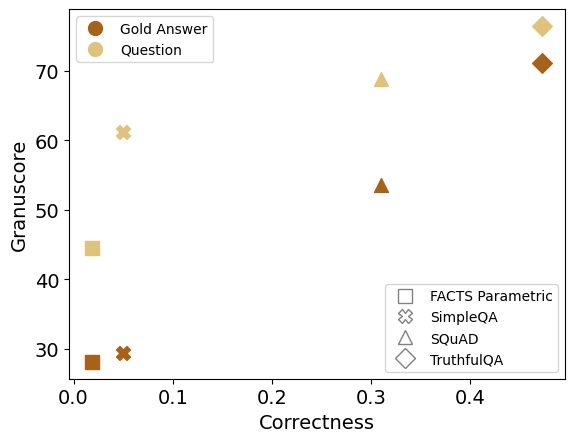

In [9]:
import matplotlib.pyplot as plt
from itertools import cycle
from matplotlib.lines import Line2D

NAME_LOOKUP = {
    'truthful_qa': 'TruthfulQA',
    'squad': 'SQuAD',
    'facts_parametric': 'FACTS Parametric',
    'simple_qa': 'SimpleQA',
}

markers = cycle(["X", "s", "^", "D"])

fig = plt.figure()

dataset_info = []
for name, marker in zip(overall.keys(), markers):
    df = overall[name]

    # Answer granularity (red)
    plt.scatter(
        df["score"],
        df["answer_granularity_gold"],
        color='#a6611a',
        marker=marker,
        s=100,
    )

    # Question granularity (blue)
    plt.scatter(
        df["score"],
        df["question_granularity"],
        color="#dfc27d",
        marker=marker,
        s=100,
    )

    handle = Line2D(
            [0], [0],
            marker=marker,
            markerfacecolor="white",
            markeredgecolor="grey",
            linestyle="None",
            markersize=10,
            label=NAME_LOOKUP.get(name),
    )

    # one legend entry per dataset (symbol only)
    dataset_info.append((df["score"], handle))

dataset_info.sort(key=lambda x: x[0])
dataset_handles = [h for _, h in dataset_info]

# Legend 1: dataset symbol
legend1 = plt.legend(
    handles=dataset_handles,
    loc="lower right",
)

# Legend 2: color meaning
color_handles = [
    Line2D([0], [0], marker='o', color='#a6611a', linestyle='None',
           markersize=10, label="Gold Answer"),
    Line2D([0], [0], marker='o', color='#dfc27d', linestyle='None',
           markersize=10, label="Question"),
]
legend2 = plt.legend(
    handles=color_handles,
)

plt.gca().add_artist(legend1)

plt.xlabel("Correctness", fontsize=14)
plt.ylabel("Granuscore", fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
fig.savefig(f"{PROJECT_DIR}/data/qa_scatter-think.pdf", bbox_inches="tight")
plt.show()

In [48]:
new = JSONLineReader().read(f"{PROJECT_DIR}/data/qa_datasets/simple_qa/qwen3-8b/batch-output-judge-qwen3-8b-simple_qa.jsonl")
old = JSONLineReader().read(f"{PROJECT_DIR}/data/qa_datasets/simple_qa/qwen3-8b/batch-output-judge-qwen3-8b-simple_qa-old.jsonl")

new = pd.DataFrame([{'custom_id': str(r['custom_id']), 'text': r['response']['body']['output'][-1]['content'][-1]['text']} for r in new])
old = pd.DataFrame([{'custom_id': str(r['custom_id']), 'text': r['response']['body']['output'][-1]['content'][-1]['text']} for r in old])

merged = new.merge(old, on="custom_id", how="inner", suffixes=("_new", "_old"))

In [49]:
diff = merged[merged["text_new"] != merged["text_old"]]
print(len(diff))

20


In [52]:
sum(
    r["response"]["body"]["output"][0]["content"][0]["text"] == "" and
    any(c["text"] for o in r["response"]["body"]["output"] for c in o["content"] if c["type"]=="output_text")
    for r in JSONLineReader().read(f"{PROJECT_DIR}/data/qa_datasets/simple_qa/qwen3-8b/batch-output-judge-qwen3-8b-simple_qa.jsonl")
)

11

In [53]:
diff

,custom_id,text_new,text_old
213,task-205,C,B
500,task-506,B,C
1162,task-1172,A,B
1497,task-1520,A,B
1906,task-1939,A,B
1955,task-1983,B,A
2015,task-2051,B,A
2123,task-2153,B,A
2740,task-2782,B,A
2743,task-2786,A,B


In [13]:
graded_stats = JSONLineReader().read(f'{PROJECT_DIR}/data/qa_datasets/outputs/graded-stats.jsonl')

In [14]:
df = pd.DataFrame.from_dict(graded_stats)
df.drop('score', axis=1, inplace=True)
df.to_latex()

'\\begin{tabular}{llrrrrr}\n\\toprule\n & info & is_correct & is_incorrect & is_not_attempted & is_given_attempted & accuracy_given_attempted \\\\\n\\midrule\n0 & qwen-8b-facts_parametric & 0.022000 & 0.925500 & 0.052500 & 0.947500 & 0.023200 \\\\\n1 & qwen-8b-squad & 0.334400 & 0.633700 & 0.031900 & 0.968100 & 0.345400 \\\\\n2 & qwen-8b-simple_qa & 0.051700 & 0.938400 & 0.009900 & 0.990100 & 0.052200 \\\\\n3 & qwen-8b-truthful_qa & 0.474400 & 0.463200 & 0.062400 & 0.937600 & 0.506000 \\\\\n4 & qwen-8b-think-squad & 0.309800 & 0.583700 & 0.106500 & 0.893500 & 0.346700 \\\\\n5 & qwen-8b-think-truthful_qa & 0.473200 & 0.389500 & 0.137300 & 0.862700 & 0.548500 \\\\\n6 & qwen-8b-think-facts_parametric & 0.018100 & 0.786100 & 0.195800 & 0.804200 & 0.022600 \\\\\n7 & qwen-8b-think-simple_qa & 0.050300 & 0.910900 & 0.038800 & 0.961200 & 0.052300 \\\\\n\\bottomrule\n\\end{tabular}\n'

In [15]:
df

,info,is_correct,is_incorrect,is_not_attempted,is_given_attempted,accuracy_given_attempted
0,qwen-8b-facts_parametric,0.0220,0.9255,0.0525,0.9475,0.0232
1,qwen-8b-squad,0.3344,0.6337,0.0319,0.9681,0.3454
2,qwen-8b-simple_qa,0.0517,0.9384,0.0099,0.9901,0.0522
3,qwen-8b-truthful_qa,0.4744,0.4632,0.0624,0.9376,0.5060
4,qwen-8b-think-squad,0.3098,0.5837,0.1065,0.8935,0.3467
5,qwen-8b-think-truthful_qa,0.4732,0.3895,0.1373,0.8627,0.5485
6,qwen-8b-think-facts_parametric,0.0181,0.7861,0.1958,0.8042,0.0226
7,qwen-8b-think-simple_qa,0.0503,0.9109,0.0388,0.9612,0.0523
